First, we try to visualize the depth and RGB images of img_0063 taken using the kv1 device

In [3]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

In [4]:
# define a helper function to display images
def display_image(image: np.ndarray,
                  title: str = "Image",
                  cmap: str | None = None) -> None:
    """
    Parameters
    ----------
    image : np.ndarray
        Image to display.

    title : str
        Figure title.

    cmap : str | None
        Colormap for grayscale images.
    """

    # ---------- Type checking ----------
    if image is None:
        raise ValueError("Image is None.")

    if not isinstance(image, np.ndarray):
        raise TypeError(
            f"Expected numpy.ndarray, got {type(image)}"
        )

    # ---------- Print useful information ----------
    print(f"Type : {type(image)}")
    print(f"Shape: {image.shape}")
    print(f"Dtype: {image.dtype}")

    # ---------- Plot ----------
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [4]:
# always check your working directory before creating a path variable
print(Path.cwd())

/Users/alexhu/UNITY_AI/3DETR/notebooks


In [5]:
# HELPER: take a .png depth image and convert it to a depth matrix in meters
def load_depth(depth_path: Path) -> np.ndarray:
    """
    Load a depth image (.png)

    Returns
    -------
    depth : ndarray
        H × W float32 depth matrix (meters)
    """
    depth = cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED)

    if depth is None:
        raise FileNotFoundError(depth_path)

    # assumed decoding method. NEED VERIFICATION
    depth = depth.astype(np.uint16)
    depth = (depth >> 3) | (depth << 13)
    depth = depth.astype(np.float32) / 1000.0

    return depth

# HELPER: take a .jpg RGB image and convert it to a RGB matrix
def load_rgb(rgb_path: Path) -> np.ndarray:
    """
    Load an RGB image (.jpg)

    Returns
    -------
    rgb : ndarray
        H × W × 3 uint8 RGB image
    """
    rgb = cv2.imread(str(rgb_path), cv2.IMREAD_COLOR)

    if rgb is None:
        raise FileNotFoundError(rgb_path)

    # convert BGR to RGB
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

    return rgb


def load_intrinsics(intrinsics_path: Path) -> np.ndarray:
    """
    Load a 3×3 camera intrinsic matrix.
    """
    return np.loadtxt(intrinsics_path)

In [6]:
# build the path for the chosen image to visualize
DATA_ROOT = Path("../rawdata/SUNRGBD")
RGBimage_path = DATA_ROOT / "kv1" / "b3dodata" / "img_0063" / "image" / "img_0063.jpg"
Depthimage_path = DATA_ROOT / "kv1" / "b3dodata" / "img_0063" / "depth" / "img_0063_abs.png"
intrinsics_path = DATA_ROOT / "kv1" / "b3dodata" / "img_0063" / "intrinsics.txt"
extrinsics_path = DATA_ROOT / "kv1" / "b3dodata" / "img_0063" / "extrinsics" / "20140915210114.txt"

# load the images using OpenCV(cv2)
rgb = load_rgb(RGBimage_path)
depth = load_depth(Depthimage_path)

# load the intrinsic parameters
intrinsics = np.loadtxt(intrinsics_path)

# load the rtilt matrix from extrinsics
rtilt = np.loadtxt(extrinsics_path)
rtilt = rtilt[:, :3]


In [7]:
print(rgb.shape)
print(rgb)

(427, 561, 3)
[[[110  93 111]
  [110  93 111]
  [109  92 108]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[110  93 111]
  [110  93 111]
  [110  93 109]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 [[109  92 110]
  [110  93 111]
  [111  94 110]
  ...
  [254 254 254]
  [254 254 254]
  [254 254 254]]

 ...

 [[ 40  22  20]
  [ 40  22  20]
  [ 40  22  20]
  ...
  [157 116  94]
  [138  94  69]
  [148 105  89]]

 [[ 40  22  20]
  [ 40  22  20]
  [ 40  22  20]
  ...
  [148 107  85]
  [134  90  65]
  [142  99  83]]

 [[ 41  21  22]
  [ 41  21  22]
  [ 40  22  22]
  ...
  [139  98  76]
  [133  87  64]
  [138  96  82]]]


In [8]:
print(intrinsics.shape)
print(intrinsics)

(3, 3)
[[520.532    0.     277.9258]
 [  0.     520.7444 215.115 ]
 [  0.       0.       1.    ]]


In [9]:
print(rtilt)
print(rtilt.shape)

[[ 0.999681  0.025146  0.002537]
 [-0.025146  0.979535  0.199699]
 [ 0.002537 -0.199699  0.979854]]
(3, 3)


In [10]:
# verfiy depth value range
print(depth.min(), depth.max())
print(depth[200:205, 300:305])

0.0 2.525
[[2.286 2.302 2.27  2.27  2.302]
 [2.27  2.27  2.27  2.27  2.27 ]
 [2.27  2.27  2.27  2.27  2.27 ]
 [2.27  2.27  2.255 2.27  2.255]
 [2.27  2.27  2.271 2.271 2.255]]


Type : <class 'numpy.ndarray'>
Shape: (427, 561, 3)
Dtype: uint8


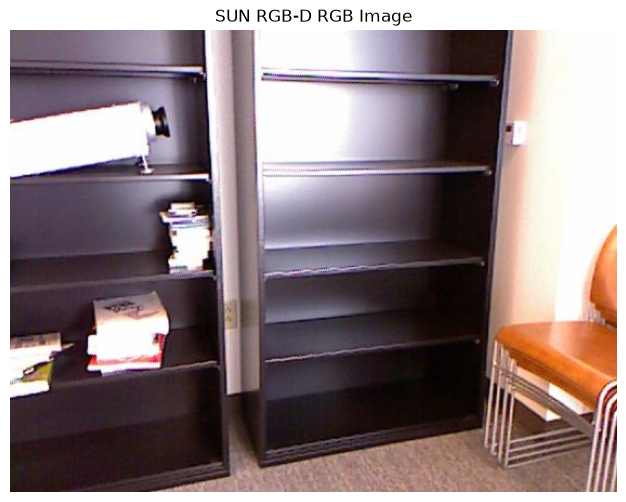

In [11]:
# Display RGB image
display_image(
    rgb,
    title="SUN RGB-D RGB Image"
)

Type : <class 'numpy.ndarray'>
Shape: (427, 561)
Dtype: float32


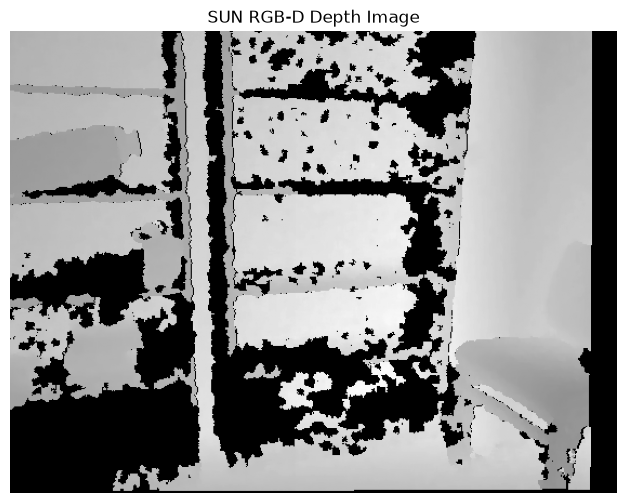

In [12]:
# Display Depth image
display_image(
    depth,
    title="SUN RGB-D Depth Image",
    cmap="gray"
)

In [7]:
# HELPER: convert depth image to point cloud 3D coordinates
def depth_to_pointcloud_vectorized(depth, rgb, intrinsics, Rtilt):

    # use the provided sensor intrinsics 
    fx = intrinsics[0, 0]
    fy = intrinsics[1, 1]
    cx = intrinsics[0, 2]
    cy = intrinsics[1, 2]

    H, W = depth.shape

    u, v = np.meshgrid(np.arange(W), np.arange(H))

    # ex. H = 3, W = 4
    # u = [[0, 1, 2, 3],
    #       [0, 1, 2, 3],
    #       [0, 1, 2, 3]]
    # v = [[0, 0, 0, 0],
    #       [1, 1, 1, 1],
    #       [2, 2, 2, 2]]

    # element-wise arithmetics to compute 3D coordinates
    Z = depth
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy

    # Construct point cloud in camera coordinates
    points = np.stack((X, Y, Z), axis=-1)

    # Keep only pixels with valid depth
    valid = Z > 0
    points = points[valid]

    # Rotate into gravity-aligned coordinate system
    points = points @ Rtilt.T

    # apply valid mask to rgb 
    if rgb.shape[:2] != depth.shape:
        raise ValueError(
            f"RGB image shape {rgb.shape[:2]} does not match depth image shape {depth.shape}."
        )

    return points, rgb[valid]

In [8]:
pointcloud, color = depth_to_pointcloud_vectorized(depth, rgb, intrinsics, rtilt)

In [15]:
print(pointcloud.shape)
print(pointcloud)

(162067, 3)
[[-0.93156357 -0.32940117  1.8249086 ]
 [-0.92826031 -0.32948426  1.82491698]
 [-0.92495705 -0.32956736  1.82492537]
 ...
 [ 0.15733897  1.10898156  1.68916839]
 [ 0.16094375  1.10889088  1.68917754]
 [ 0.16454853  1.10880021  1.68918669]]


In [9]:
import open3d as o3d


def visualize_point_cloud(
    points: np.ndarray,
    colors: np.ndarray | None = None,
    window_name: str = "Point Cloud",
    point_size: float = 2.0,
):
    """
    Visualize a point cloud using Open3D.

    Parameters
    ----------
    points : ndarray, shape (N,3)
        XYZ coordinates of the point cloud.

    colors : ndarray, shape (N,3), optional
        RGB values in either
            [0,255] uint8
        or
            [0,1] float.

    window_name : str
        Title of the visualization window.

    point_size : float
        Size of rendered points.
    """

    # ----------------------------
    # Sanity checks
    # ----------------------------

    if not isinstance(points, np.ndarray):
        raise TypeError("points must be a NumPy array")

    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(
            f"Expected points of shape (N,3), got {points.shape}"
        )

    # ----------------------------
    # Create Open3D PointCloud
    # ----------------------------

    pcd = o3d.geometry.PointCloud()

    pcd.points = o3d.utility.Vector3dVector(points)

    # ----------------------------
    # Optional colors
    # ----------------------------

    if colors is not None:

        if colors.shape != points.shape:
            raise ValueError(
                "colors must have the same shape as points"
            )

        colors = colors.astype(np.float64)

        # Normalize if necessary
        if colors.max() > 1.0:
            colors /= 255.0

        pcd.colors = o3d.utility.Vector3dVector(colors)

    # ----------------------------
    # Visualizer
    # ----------------------------

    vis = o3d.visualization.Visualizer()

    vis.create_window(window_name)

    vis.add_geometry(pcd)

    render_option = vis.get_render_option()
    render_option.point_size = point_size

    vis.run()

    vis.destroy_window()

In [11]:
visualize_point_cloud(pointcloud, color, "Point Cloud", 2.0)